In [1]:
import os
import shutil
import pandas as pd

folders = [r"C:\Users\SIDDHI\Downloads\test",
          r"C:\Users\SIDDHI\Downloads\train",
          r"C:\Users\SIDDHI\Downloads\valid"]  

# Target folder to merge all the images
target_folder = r"C:\Users\SIDDHI\Downloads\all_images"
os.makedirs(target_folder, exist_ok=True)

# Creating empty list to store labels
image_files = []
labels = []

for fname in os.listdir(target_folder):
    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        color = fname.split('_')[0]
        image_files.append(fname)
        labels.append(color)

print(len(image_files), len(labels)) 

df = pd.DataFrame({'filename': image_files, 'label': labels})
df.to_csv('labels.csv', index=False)
df.head()

1248 1248


,filename,label
0,black_0a0502_png.rf.2e169e06099bae980871ebb0ac...,black
1,black_0a0502_png.rf.c106cdc05fbb40be1731a49712...,black
2,black_0a0502_png.rf.f25c6d2300e6f0bae3e45f2612...,black
3,black_0a0502_png.rf.f47672bde35c88f67e86a114e4...,black
4,black_0a0502_png.rf.fda935cc82dc60b4bcd4ace574...,black


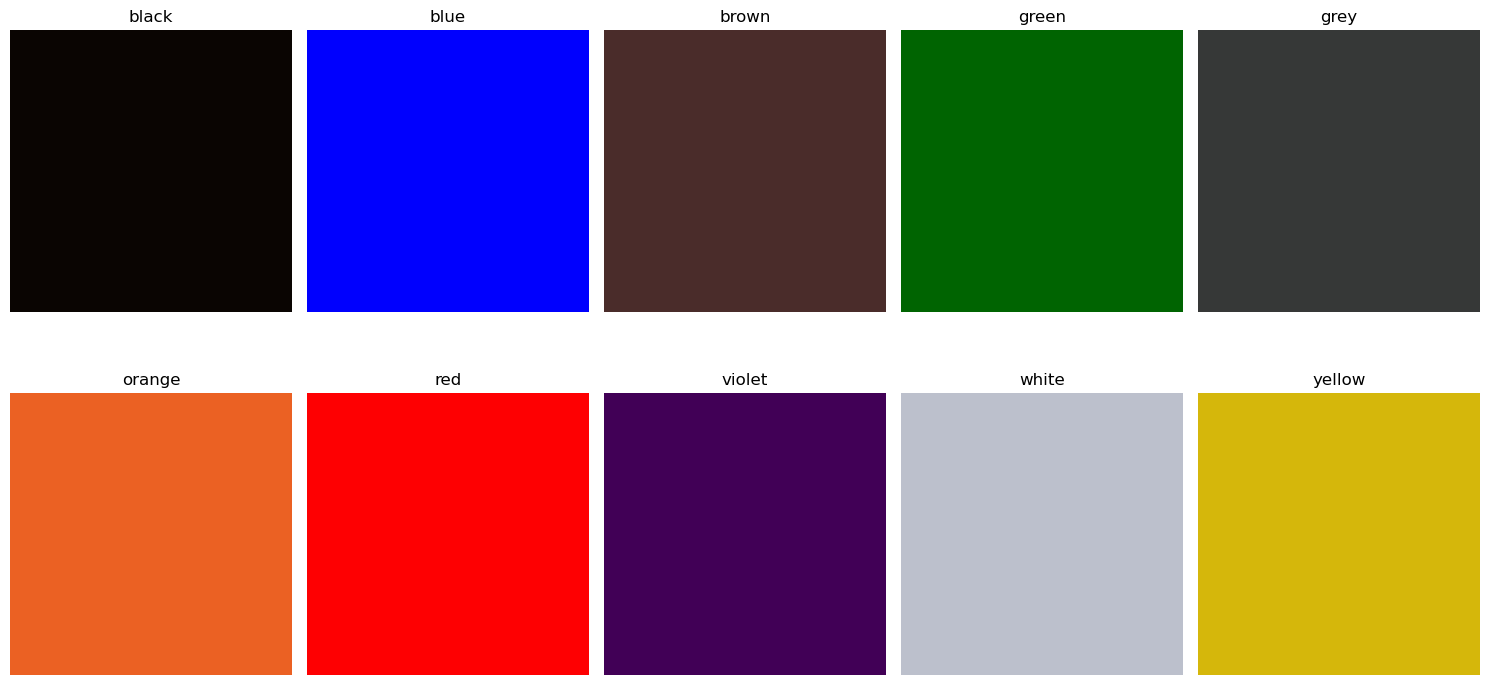

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

colors = df['label'].unique()
plt.figure(figsize=(15, 8))

for i, color in enumerate(colors[:10]): 
    sample = df[df['label'] == color]['filename'].iloc[0]
    img_path = os.path.join(target_folder, sample)
    
    img = Image.open(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
print(len(train_df), len(val_df))

998 250


In [4]:
# Set up image data generators

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=r"C:\Users\SIDDHI\Downloads\all_images",   
    x_col='filename',
    y_col='label',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=r"C:\Users\SIDDHI\Downloads\all_images",
    x_col='filename',
    y_col='label',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

Found 998 validated image filenames belonging to 10 classes.
Found 250 validated image filenames belonging to 10 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

# Build the CNN model

model = Sequential()
model.add(Conv2D(32, (3,3), strides=(1,1), activation='relu', padding='valid', input_shape=(64,64,3)))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(Conv2D(64, (3,3), strides=(1,1), activation='relu', padding='valid'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\Users\SIDDHI\New anaconda\envs\tfenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from keras.callbacks import EarlyStopping
estop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

In [8]:
# Train the model
m=model.fit(train_generator, epochs=100, validation_data=val_generator, callbacks=[estop])

C:\Users\SIDDHI\New anaconda\envs\tfenv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 463ms/step - accuracy: 0.6713 - loss: 0.9576 - val_accuracy: 0.8920 - val_loss: 0.2868
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 391ms/step - accuracy: 0.8517 - loss: 0.3763 - val_accuracy: 0.9080 - val_loss: 0.2316
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 400ms/step - accuracy: 0.8848 - loss: 0.2490 - val_accuracy: 0.8960 - val_loss: 0.2245
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 400ms/step - accuracy: 0.9188 - loss: 0.1967 - val_accuracy: 0.9080 - val_loss: 0.2016
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 398ms/step - accuracy: 0.9279 - loss: 0.1705 - val_accuracy: 0.9480 - val_loss: 0.1384
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 405ms/step - accuracy: 0.9599 - loss: 0.1055 - val_accuracy: 0.9480 - val_loss: 0.1159
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 408ms/step - accuracy: 0.9609 - loss: 0.0977 - val_accuracy: 0.9440 - val_loss: 0.1157
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 401ms/step - accuracy: 0.9719 - loss: 0.0591 - 

In [9]:
loss, accuracy = model.evaluate(val_generator)
print("Test accuracy:", accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.9960 - loss: 0.0422
Test accuracy: 0.9959999918937683


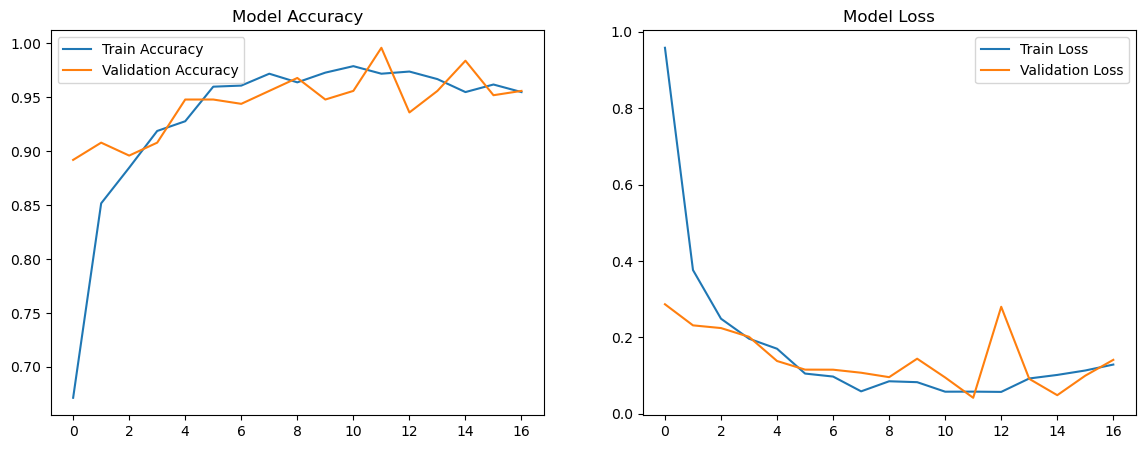

In [10]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(m.history['accuracy'], label='Train Accuracy')
plt.plot(m.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(m.history['loss'], label='Train Loss')
plt.plot(m.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

In [11]:
class_names = ['Black', 'Blue', 'Brown', 'Green', 'Orange',
               'Pink', 'Purple', 'Red', 'White', 'Yellow']

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step


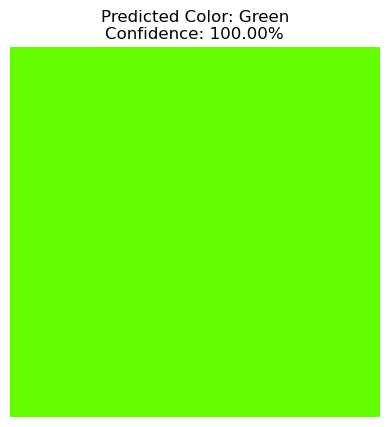

Predicted Color: Green
Confidence: 1.0


In [15]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = r"C:\Users\SIDDHI\Downloads\test\green\66ff00_png.rf.b513af9705e5d38119119b80e74f5c14.jpg"

img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)
predicted_color = class_names[predicted_class]
confidence = np.max(prediction)

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted Color: {predicted_color}\nConfidence: {confidence:.2%}")
plt.show()

print("Predicted Color:", predicted_color)
print("Confidence:", confidence)